  sentence splitting: Excluded 2 questions from metrics calculation.
  markdown splitting: Excluded 2 questions from metrics calculation.
  markdown and sentence splitting: Excluded 2 questions from metrics calculation.


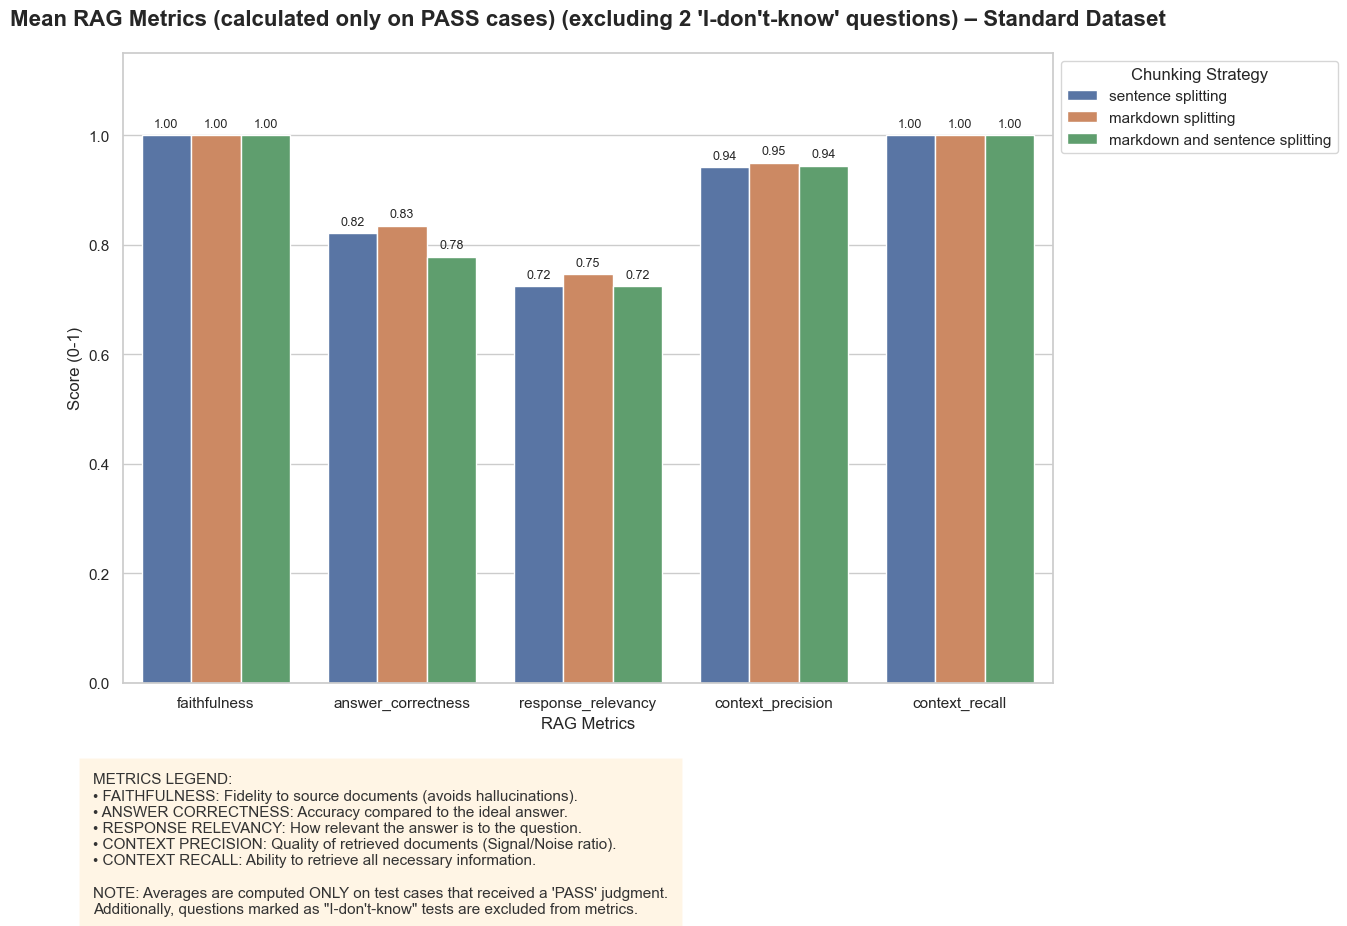

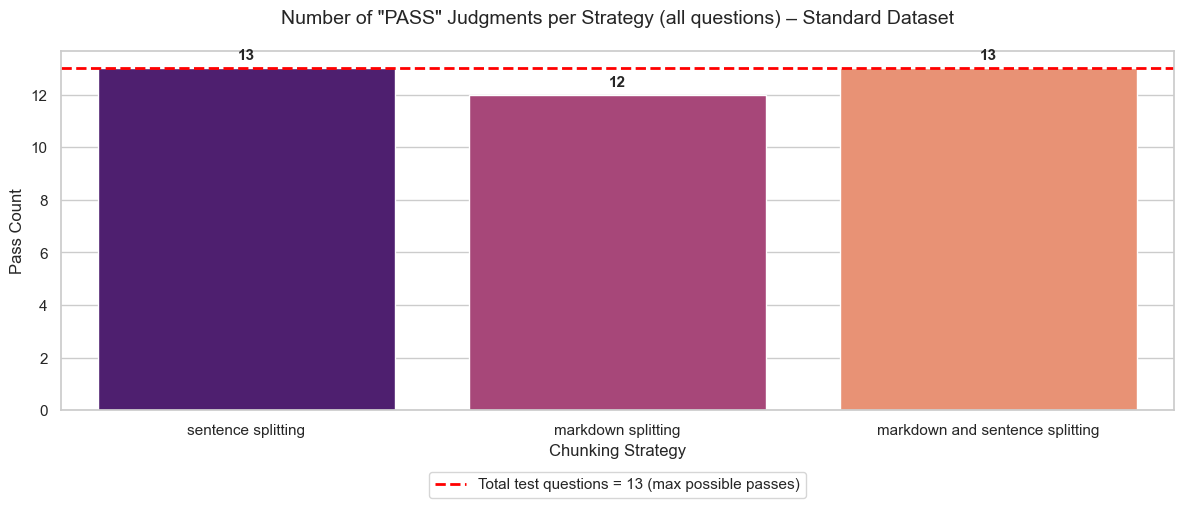


--- SUMMARY JUDGE PASS COUNT (Standard) ---
sentence splitting: 13 pass / 13 total (rate: 100.0%)
markdown splitting: 12 pass / 13 total (rate: 92.3%)
markdown and sentence splitting: 13 pass / 13 total (rate: 100.0%)

--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY (Standard) ---
Excluded questions: ["l aula T dell'edificio A è libera il giorno 20 marzo 2026?", 'dimmi i corsi disponibili del dipartimento di musicologia']
SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.821, response_relevancy: 0.725, context_precision: 0.942, context_recall: 1.000
MARKDOWN SPLITTING: faithfulness: 1.000, answer_correctness: 0.835, response_relevancy: 0.747, context_precision: 0.950, context_recall: 1.000
MARKDOWN AND SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.778, response_relevancy: 0.725, context_precision: 0.944, context_recall: 1.000




In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
name_map = {
    'from_index_sentence_results': 'sentence splitting',
    'from_index_markdown_chunking_results': 'markdown splitting',
    'from_index_markdown_and_sentence_results': 'markdown and sentence splitting'
}

metrics = ['faithfulness', 'answer_correctness', 'response_relevancy', 'context_precision', 'context_recall']

# ------------------------------------------------------------
# Function to process a set of experiments and generate plots
# ------------------------------------------------------------
def process_experiment_set(file_list, dataset_name, exclude_questions=None):
    """
    file_list: list of CSV file paths
    dataset_name: string, e.g. "Standard" or "Big"
    exclude_questions: list of strings (question texts or substrings) to exclude from metrics calculation.
                      These rows are kept for pass count but skipped for metrics averages.
    """
    # Check if all files exist
    missing_files = [f for f in file_list if not os.path.exists(f)]
    if missing_files:
        print(f"Warning: {dataset_name} dataset - missing files: {missing_files}")
        print(f"Skipping {dataset_name} dataset.\n")
        return
    
    results = []
    pass_counts = []
    
    for file_path in file_list:
        raw_name = os.path.basename(file_path).replace('.csv', '')
        base_name = raw_name.replace('_big', '')
        label = name_map.get(base_name, base_name)
        
        try:
            df = pd.read_csv(file_path)
            
            # ---- Pass count statistics (on full data) ----
            if 'judge_result' in df.columns:
                n_pass = (df['judge_result'] == 'pass').sum()
                n_total = len(df)
                pass_counts.append({
                    'strategy': label,
                    'pass_count': n_pass,
                    'total': n_total,
                    'pass_rate': n_pass / n_total if n_total > 0 else 0
                })
                
                # ---- Filter rows for metrics: exclude questions that are "I don't know" tests ----
                df_metrics = df.copy()
                if exclude_questions:
                    # Exact match (or use .str.contains for substring)
                    mask = ~df_metrics['question'].isin(exclude_questions)
                    df_metrics = df_metrics[mask]
                    print(f"  {label}: Excluded {len(df) - len(df_metrics)} questions from metrics calculation.")
                
                # Now compute metrics only on PASS rows among the filtered set
                df_pass_metrics = df_metrics[df_metrics['judge_result'] == 'pass']
                if len(df_pass_metrics) > 0:
                    row = df_pass_metrics[metrics].mean().to_dict()
                else:
                    row = {m: np.nan for m in metrics}
                row['strategy'] = label
                results.append(row)
            else:
                print(f"Warning: {label} ({dataset_name}) has no 'judge_result' column")
                
        except Exception as e:
            print(f"Error processing {label} ({dataset_name}): {e}")
    
    if not results:
        print(f"No valid data for {dataset_name}")
        return
    
    df_results = pd.DataFrame(results)
    df_pass = pd.DataFrame(pass_counts) if pass_counts else None
    
    # ---------- Plot 1: Mean RAG metrics (only on PASS cases, excluding specific questions) ----------
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 10))
    df_melted = df_results.melt(id_vars='strategy', value_vars=metrics, var_name='Metric', value_name='Score')
    df_melted_clean = df_melted.dropna(subset=['Score'])
    
    ax1 = sns.barplot(data=df_melted_clean, x='Metric', y='Score', hue='strategy')
    
    title_suffix = ""
    if exclude_questions:
        title_suffix = f" (excluding {len(exclude_questions)} 'I-don\'t-know' questions)"
    plt.title(f'Mean RAG Metrics (calculated only on PASS cases){title_suffix} – {dataset_name} Dataset', 
              fontsize=16, pad=20, fontweight='bold')
    plt.ylim(0, 1.15)
    plt.ylabel('Score (0-1)', fontsize=12)
    plt.xlabel('RAG Metrics', fontsize=12)
    plt.legend(title='Chunking Strategy', bbox_to_anchor=(1, 1), loc='upper left')
    
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.2f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), 
                         textcoords='offset points', fontsize=9)
    
    description_text = (
        "METRICS LEGEND:\n"
        "• FAITHFULNESS: Fidelity to source documents (avoids hallucinations).\n"
        "• ANSWER CORRECTNESS: Accuracy compared to the ideal answer.\n"
        "• RESPONSE RELEVANCY: How relevant the answer is to the question.\n"
        "• CONTEXT PRECISION: Quality of retrieved documents (Signal/Noise ratio).\n"
        "• CONTEXT RECALL: Ability to retrieve all necessary information.\n\n"
        "NOTE: Averages are computed ONLY on test cases that received a 'PASS' judgment.\n"
        f"{'Additionally, questions marked as \"I-don\'t-know\" tests are excluded from metrics.' if exclude_questions else ''}"
    )
    
    plt.figtext(0.1, 0.02, description_text, fontsize=11, color="#333333", 
                bbox={"facecolor":"orange", "alpha":0.1, "pad":10}, 
                horizontalalignment='left')
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    # ---------- Plot 2: Pass count with horizontal line (includes all questions) ----------
    if df_pass is not None:
        total_questions = df_pass['total'].iloc[0]
        # Increase figure size to accommodate legend outside
        plt.figure(figsize=(12, 6))  # wider than before (was 10,6)
        ax2 = sns.barplot(data=df_pass, x='strategy', y='pass_count', 
                        hue='strategy', palette='magma', legend=False)
        
        ax2.axhline(y=total_questions, color='red', linestyle='--', linewidth=2,
                    label=f'Total test questions = {total_questions} (max possible passes)')
        
        plt.title(f'Number of "PASS" Judgments per Strategy (all questions) – {dataset_name} Dataset', 
                fontsize=14, pad=20)
        plt.ylabel('Pass Count')
        plt.xlabel('Chunking Strategy')
        
        # Place legend outside the plot area (to the right)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)
        plt.tight_layout(rect=[0, 0, 1, 0.9])
                
        for p in ax2.patches:
            ax2.annotate(f"{int(p.get_height())}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), 
                        textcoords='offset points', fontsize=11, fontweight='bold')
        
        plt.show()
        
        # Print summary
        print(f"\n--- SUMMARY JUDGE PASS COUNT ({dataset_name}) ---")
        for _, r in df_pass.iterrows():
            print(f"{r['strategy']}: {int(r['pass_count'])} pass / {r['total']} total (rate: {r['pass_rate']:.1%})")
    else:
        print(f"No 'judge_result' data found for {dataset_name}")
    
    # Print metric summary
    print(f"\n--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY ({dataset_name}) ---")
    if exclude_questions:
        print(f"Excluded questions: {exclude_questions}")
    for _, r in df_results.iterrows():
        metrics_str = ", ".join([f"{m}: {r[m]:.3f}" for m in metrics if pd.notna(r[m])])
        print(f"{r['strategy'].upper()}: {metrics_str}")
    print("\n" + "="*80 + "\n")

# ------------------------------------------------------------
# Define file lists for the two experiment sets
# ------------------------------------------------------------
normal_files = [
    'evals/experiments/from_index_sentence_results.csv',
    'evals/experiments/from_index_markdown_chunking_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_results.csv'
]

big_files = [
    'evals/experiments/from_index_sentence_big_results.csv',
    'evals/experiments/from_index_markdown_chunking_big_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_big_results.csv'
]

# ------------------------------------------------------------
# Define questions to exclude from metrics (exact text as in CSV)
# ------------------------------------------------------------
questions_to_exclude = [
    "l aula T dell'edificio A è libera il giorno 20 marzo 2026?",
    "dimmi i corsi disponibili del dipartimento di musicologia"
]

# ------------------------------------------------------------
# Run for Standard dataset only (big files are missing)
# ------------------------------------------------------------
process_experiment_set(normal_files, "Standard", exclude_questions=questions_to_exclude)

# Uncomment when big files become available
# process_experiment_set(big_files, "Big", exclude_questions=questions_to_exclude)

  sentence splitting: Excluded 2 questions from metrics calculation.
  markdown splitting: Excluded 2 questions from metrics calculation.
  markdown and sentence splitting: Excluded 2 questions from metrics calculation.


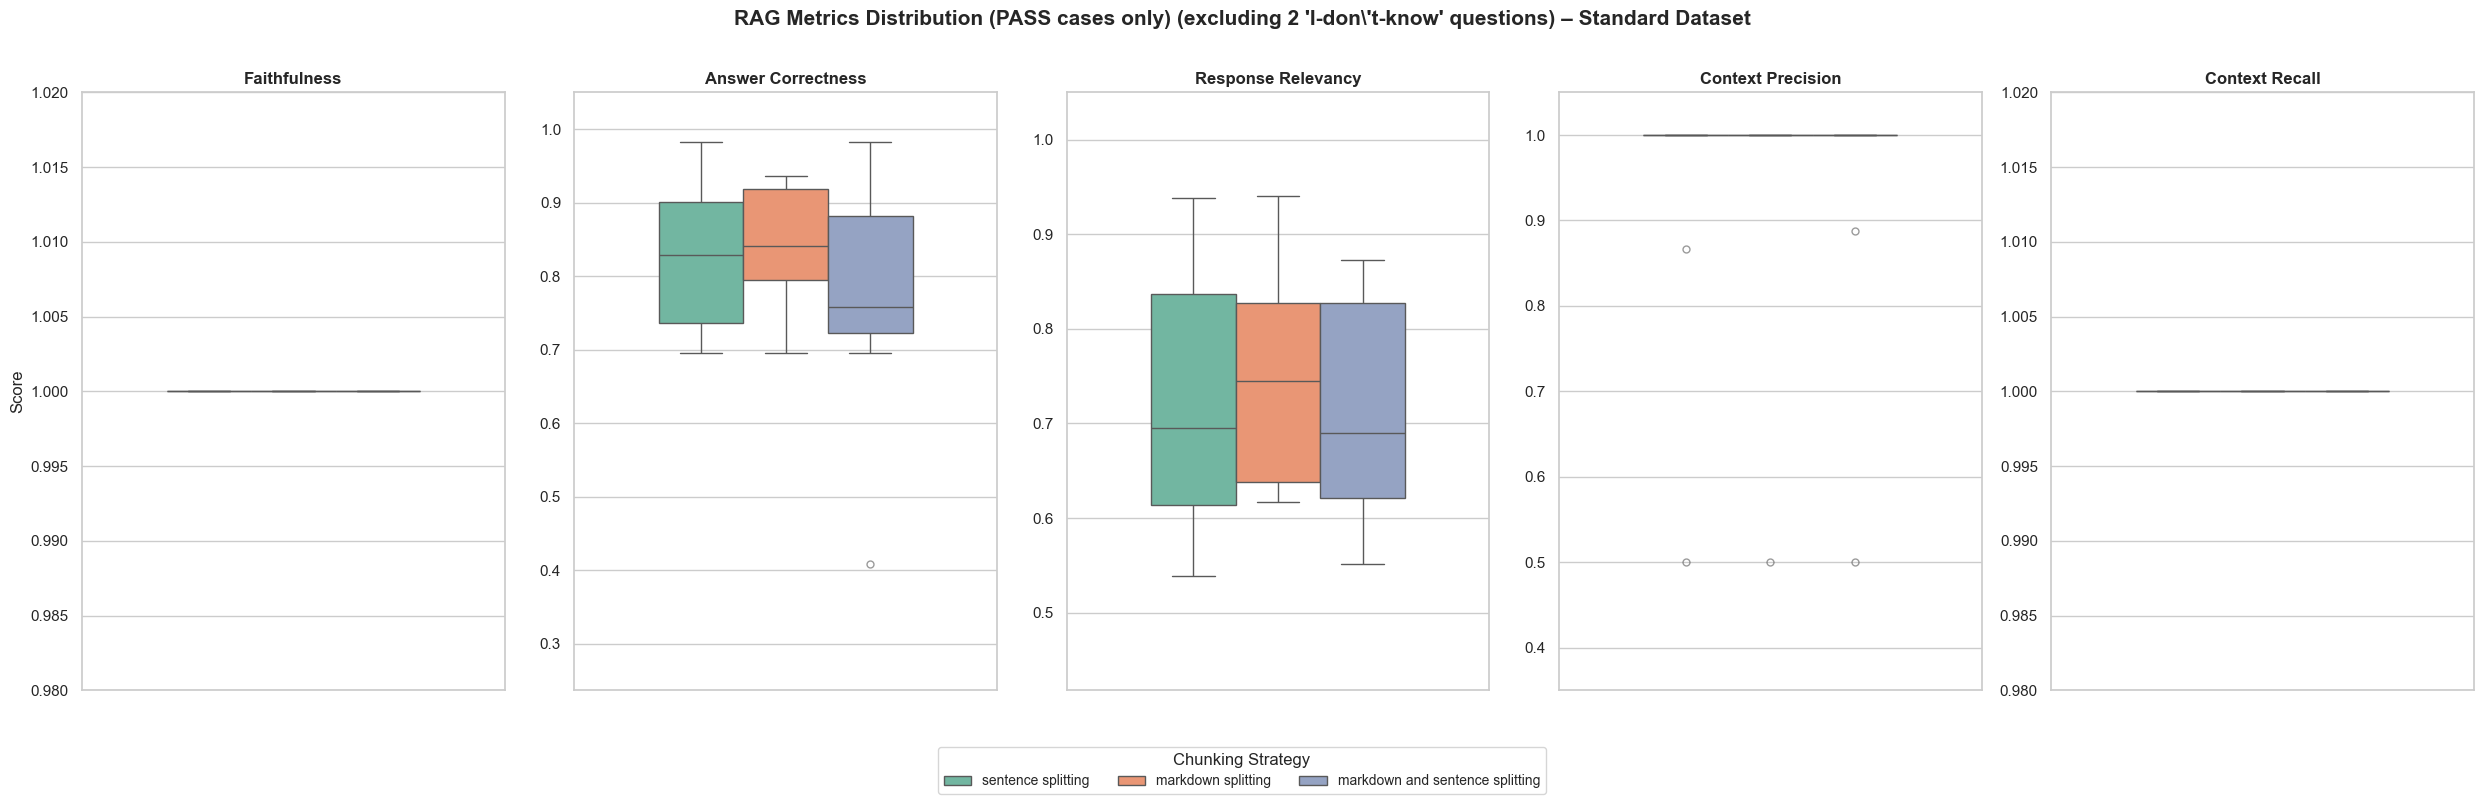

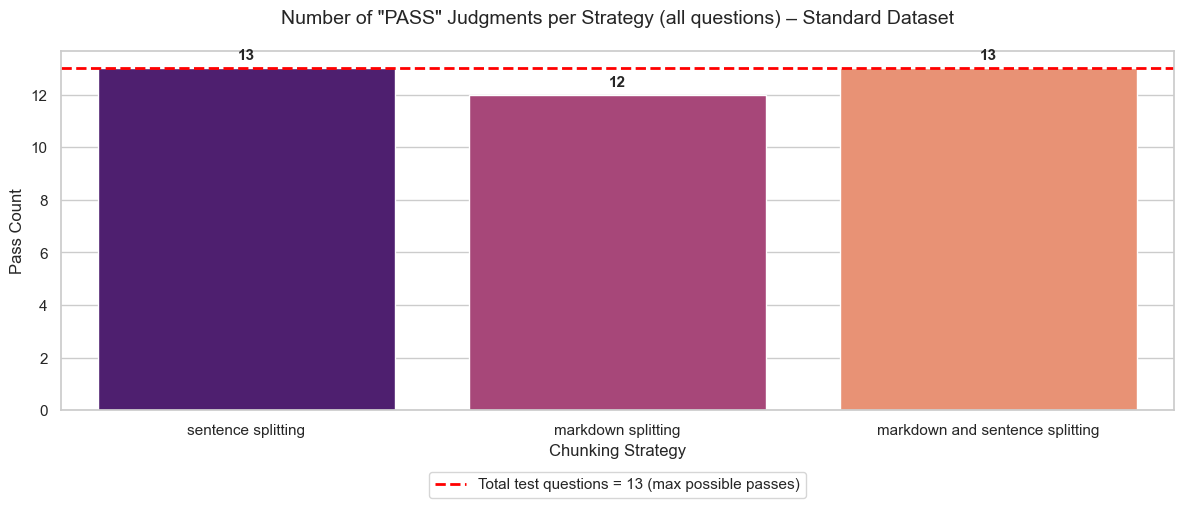


--- SUMMARY JUDGE PASS COUNT (Standard) ---
sentence splitting: 13 pass / 13 total (rate: 100.0%)
markdown splitting: 12 pass / 13 total (rate: 92.3%)
markdown and sentence splitting: 13 pass / 13 total (rate: 100.0%)

--- TEXTUAL DATA SUMMARY – METRICS ON PASS CASES ONLY (Standard) ---
Excluded questions: ["l aula T dell'edificio A è libera il giorno 20 marzo 2026?", 'dimmi i corsi disponibili del dipartimento di musicologia']
SENTENCE SPLITTING: faithfulness: median=1.000, IQR=[1.000-1.000], answer_correctness: median=0.828, IQR=[0.737-0.901], response_relevancy: median=0.695, IQR=[0.614-0.837], context_precision: median=1.000, IQR=[1.000-1.000], context_recall: median=1.000, IQR=[1.000-1.000]
MARKDOWN SPLITTING: faithfulness: median=1.000, IQR=[1.000-1.000], answer_correctness: median=0.841, IQR=[0.794-0.918], response_relevancy: median=0.745, IQR=[0.638-0.828], context_precision: median=1.000, IQR=[1.000-1.000], context_recall: median=1.000, IQR=[1.000-1.000]
MARKDOWN AND SENTENCE

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
name_map = {
    'from_index_sentence_results': 'sentence splitting',
    'from_index_markdown_chunking_results': 'markdown splitting',
    'from_index_markdown_and_sentence_results': 'markdown and sentence splitting'
}

metrics = ['faithfulness', 'answer_correctness', 'response_relevancy', 'context_precision', 'context_recall']

# ------------------------------------------------------------
# Function to process a set of experiments and generate plots
# ------------------------------------------------------------
def process_experiment_set(file_list, dataset_name, exclude_questions=None):
    """
    file_list: list of CSV file paths
    dataset_name: string, e.g. "Standard" or "Big"
    exclude_questions: list of strings (question texts) to exclude from metrics calculation.
                      These rows are kept for pass count but skipped for metrics averages.
    """
    missing_files = [f for f in file_list if not os.path.exists(f)]
    if missing_files:
        print(f"Warning: {dataset_name} dataset - missing files: {missing_files}")
        print(f"Skipping {dataset_name} dataset.\n")
        return

    results_rows = []   # one row per (strategy, metric, score) for box plot
    pass_counts = []

    for file_path in file_list:
        raw_name = os.path.basename(file_path).replace('.csv', '')
        base_name = raw_name.replace('_big', '')
        label = name_map.get(base_name, base_name)

        try:
            df = pd.read_csv(file_path)

            # ---- Pass count statistics (on full data) ----
            if 'judge_result' in df.columns:
                n_pass = (df['judge_result'] == 'pass').sum()
                n_total = len(df)
                pass_counts.append({
                    'strategy': label,
                    'pass_count': n_pass,
                    'total': n_total,
                    'pass_rate': n_pass / n_total if n_total > 0 else 0
                })

                # ---- Filter rows for metrics: exclude "I don't know" test questions ----
                df_metrics = df.copy()
                if exclude_questions:
                    mask = ~df_metrics['question'].isin(exclude_questions)
                    df_metrics = df_metrics[mask]
                    print(f"  {label}: Excluded {len(df) - len(df_metrics)} questions from metrics calculation.")

                # Compute metrics only on PASS rows among the filtered set
                df_pass_metrics = df_metrics[df_metrics['judge_result'] == 'pass']

                # Collect individual scores per row for box plot (long format)
                for _, row in df_pass_metrics.iterrows():
                    for metric in metrics:
                        if pd.notna(row[metric]):
                            results_rows.append({
                                'strategy': label,
                                'metric': metric,
                                'score': row[metric]
                            })
            else:
                print(f"Warning: {label} ({dataset_name}) has no 'judge_result' column")

        except Exception as e:
            print(f"Error processing {label} ({dataset_name}): {e}")

    if not results_rows:
        print(f"No valid data for {dataset_name}")
        return

    df_long = pd.DataFrame(results_rows)
    df_pass = pd.DataFrame(pass_counts) if pass_counts else None

    # ---------- Plot 1: Box plot – one subplot per metric ----------
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 7), sharey=False)

    title_suffix = f" (excluding {len(exclude_questions)} 'I-don\\'t-know' questions)" if exclude_questions else ""
    fig.suptitle(
        f'RAG Metrics Distribution (PASS cases only){title_suffix} – {dataset_name} Dataset',
        fontsize=15, fontweight='bold', y=1.01
    )

    strategies = df_long['strategy'].unique()
    palette = sns.color_palette('Set2', len(strategies))

    for ax, metric in zip(axes, metrics):
        df_metric = df_long[df_long['metric'] == metric]

        sns.boxplot(
            data=df_metric,
            x='metric',
            y='score',
            hue='strategy',
            palette='Set2',
            width=0.6,
            flierprops=dict(marker='o', markersize=5, alpha=0.6),
            ax=ax
        )

        # Auto-zoom: add a small margin around actual data range
        min_val = df_metric['score'].min()
        max_val = df_metric['score'].max()
        spread = max_val - min_val
        margin = max(spread * 0.3, 0.02)  # at least 0.02 of margin
        ax.set_ylim(max(0, min_val - margin), min(1.05, max_val + margin))

        ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.set_ylabel('Score' if metric == metrics[0] else '')
        ax.get_legend().remove()

    # Single shared legend outside the subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Chunking Strategy',
            loc='lower center', bbox_to_anchor=(0.5, -0.12),
            ncol=len(strategies), fontsize=10)

    plt.tight_layout()
    plt.show()

    # ---------- Plot 2: Pass count with horizontal line (includes all questions) ----------
    if df_pass is not None:
        total_questions = df_pass['total'].iloc[0]
        plt.figure(figsize=(12, 6))
        ax2 = sns.barplot(data=df_pass, x='strategy', y='pass_count',
                          hue='strategy', palette='magma', legend=False)

        ax2.axhline(y=total_questions, color='red', linestyle='--', linewidth=2,
                    label=f'Total test questions = {total_questions} (max possible passes)')

        plt.title(f'Number of "PASS" Judgments per Strategy (all questions) – {dataset_name} Dataset',
                  fontsize=14, pad=20)
        plt.ylabel('Pass Count')
        plt.xlabel('Chunking Strategy')
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)
        plt.tight_layout(rect=[0, 0, 1, 0.9])

        for p in ax2.patches:
            ax2.annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9),
                         textcoords='offset points', fontsize=11, fontweight='bold')

        plt.show()

        print(f"\n--- SUMMARY JUDGE PASS COUNT ({dataset_name}) ---")
        for _, r in df_pass.iterrows():
            print(f"{r['strategy']}: {int(r['pass_count'])} pass / {r['total']} total (rate: {r['pass_rate']:.1%})")
    else:
        print(f"No 'judge_result' data found for {dataset_name}")

    # Print metric summary (median + IQR for box plots)
    print(f"\n--- TEXTUAL DATA SUMMARY – METRICS ON PASS CASES ONLY ({dataset_name}) ---")
    if exclude_questions:
        print(f"Excluded questions: {exclude_questions}")
    for strategy in df_long['strategy'].unique():
        df_s = df_long[df_long['strategy'] == strategy]
        parts = []
        for metric in metrics:
            vals = df_s[df_s['metric'] == metric]['score'].dropna()
            if len(vals) > 0:
                parts.append(f"{metric}: median={vals.median():.3f}, IQR=[{vals.quantile(0.25):.3f}-{vals.quantile(0.75):.3f}]")
        print(f"{strategy.upper()}: {', '.join(parts)}")
    print("\n" + "=" * 80 + "\n")

# ------------------------------------------------------------
# Define file lists for the two experiment sets
# ------------------------------------------------------------
normal_files = [
    'evals/experiments/from_index_sentence_results.csv',
    'evals/experiments/from_index_markdown_chunking_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_results.csv'
]

big_files = [
    'evals/experiments/from_index_sentence_big_results.csv',
    'evals/experiments/from_index_markdown_chunking_big_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_big_results.csv'
]

# ------------------------------------------------------------
# Define questions to exclude from metrics (exact text as in CSV)
# ------------------------------------------------------------
questions_to_exclude = [
    "l aula T dell'edificio A è libera il giorno 20 marzo 2026?",
    "dimmi i corsi disponibili del dipartimento di musicologia"
]

# ------------------------------------------------------------
# Run for Standard dataset only (big files are missing)
# ------------------------------------------------------------
process_experiment_set(normal_files, "Standard", exclude_questions=questions_to_exclude)

# Uncomment when big files become available
# process_experiment_set(big_files, "Big", exclude_questions=questions_to_exclude)